# Synthetic Control - Reducing Smoking In California

In this notebook we practice the synthetic control method by reproducing the results from the Abadie, Diamond, Hainmueller (2007) paper. In this paper the authors studied the effect of proposition 99, a large tobacco control programme implemented in California, on the number of packets of cigarettes consumed per capita. Before the synthetic control method was introduced, a researcher would have run a timeseries or a comparative study. Timeseries studies are fine when the short term effect is large, but as time goes on it becomes difficult to seperate noise/further shocks from the effect of the treatment. Comparative studies whilst very popular have the drawback that comparisons are selected based on subjective perceptions of similarity with the treated, furthermore, when the units of interest are large aggregates (e.g. countries, states, regions etc...) it is likely that there is not a single unit that is comparable to the treated. Synthetic control was introduced in response to these issues. Further details are below, at a high level, synthetic control builds a counterfactual of the treated by selecting the weighted average of units in the donor pool that minimises some distance metric between the covariates that we think are important. For example, when the UK left the EU, to measure the effect on the economy we could build a *synthetic UK* that is some linear combination of other similar Europena countries such that the weighted sum across some indicators we think are important, like unemployment, inflation and per capita GDP is as similar as possible to the UK's own figures.

This notebook is structured as follows...

## Synthetic Control Estimator

Here we describe the set up and estimation steps in synthetic control. Firstly, we have $J+1$ units, $1, 2, ..., J+1$ assume that unit $1$ is our unit of interest - the treated unit. For each unit $j$ and time $t$ we observe the outcome of interested $Y_{jt}. Every time period $t$ up to $T_{0}$ is the preintervention period, and all time periods thereafter are the post intervention period. Each unit, $j$, is asscoiated with a $K\text{x}1$ covariate vector $X_{j} = [x_{j1}, ..., x_{jk}]$. The $K\text{x}J$ matrix $X_{0} = [X_{2},...,X_{J+1}]$ collects these values for the untreated units. For each unit $j$ we define $Y^{N}_{jt}$ to be the potential response without intervention and $Y^{I}_{jt}$ to be the potential response under intervention - these are the potential outcomes in Rubin's framework. Given this the effect we are interested in is

$$
\tau_{1t} = Y^{I}_{1t} - Y^{N}_{1t}
$$

A couple of things to note here. First, unit $1$ is exposed to the treatment therefore, $Y^{I}_{1t} = Y_{1t}$ and we only need to estimate the outcome under no treatment for $t>T_{0}$. Furthermore, notice how the equation allows for varying effects with $t$, this is important because interventions may not effect the metric of interest instantly, or their effect may dissipate i.e. the effect is non-linear over time.

Now we have our set up we cant talk about our estimator. The synthetic control estimator of $Y^{N}_{1t}$ is:

$$
\hat{Y}^{N}_{1t} = \sum_{j=2}^{J+1}w_{j}Y_{jt}
$$

$$
\tau_{1t} = Y^{I}_{1t} - \hat{Y}^{N}_{1t} 
$$

Now we need to estimate the $J\text{x}1$ weight vector $W=(w_{2},...,w_{j+1})$. We do this by selecting the $W^{*}$ that minimises:

$$
||X_{1} - X_{0}W||_{v}
$$

Subject to the restrictions, 

$$
\sum_{j=2}^{j}w_{j} = 1
$$ 
$$
\forall j \space w_{j} \ge 0
$$

This is a weighted norm, weighted by the $K\text{x}1$ vector $V$, therefore it is equal to

$$
(\sum_{i=1}^{k}v_{i}(X_{i1} - w_{2}X_{i2} - ... - w_{j+1}X_{ij+1})^{2})^{\frac{1}{2}}
$$

$V$ reflects the relative importance each of the predictors in $X$. The estimated treatment effect is therefor,

$$
\tau_{1t} = Y_{1t} - \sum_{j=2}^{j+1}w^{*}_{j}Y_{jt}
$$

All that remains is the choice of $V$. We could select the inverse of the variance, or we could select $V$ such that the pre-treatment prediction error is minimised. Below we will experiment with different choices.

In [10]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fmin_slsqp
from functools import partial
from get_data import load_smoking

## Load Data

- describe dataset shape and columns

In [3]:
df = load_smoking()
df.head()

,state,year,cigsale,lnincome,beer,age15to24,retprice,california,after_treatment
0,Alabama,1970,89.800003,NaN,NaN,0.178862,39.599998,False,False
1,Alabama,1971,95.400002,NaN,NaN,0.179928,42.700001,False,False
2,Alabama,1972,101.099998,9.498476,NaN,0.180994,42.299999,False,False
3,Alabama,1973,102.900002,9.550107,NaN,0.182060,42.099998,False,False
4,Alabama,1974,108.199997,9.537163,NaN,0.183126,43.099998,False,False


## Naive Comparatison

- Why its not good 

- Show the chart of cali vs us pre treatment and post

- Its equivalent to a uniform synthetic control

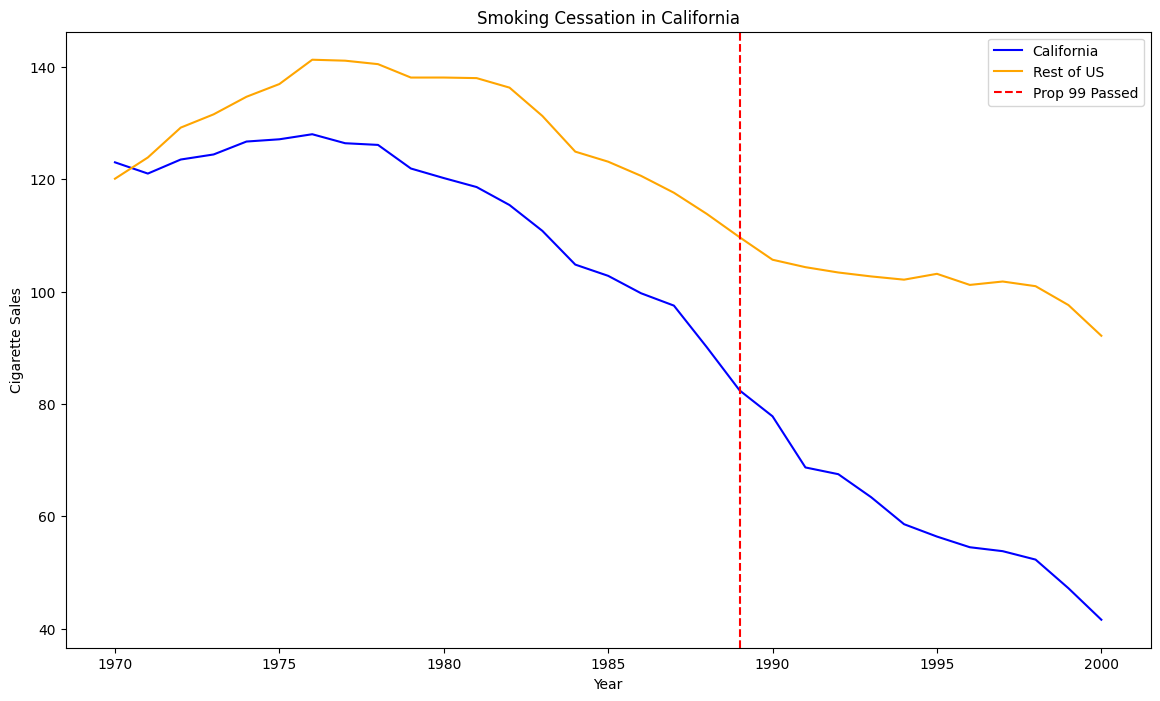

In [6]:
california = df[df["state"] == "California"]
rest_of_us = df[df["state"] != "California"]

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(california["year"], california["cigsale"], label="California", color="blue")
ax.plot(rest_of_us.groupby("year")["cigsale"].mean(), label="Rest of US", color="orange")
ax.axvline(x=1989, color="red", linestyle="--", label="Prop 99 Passed")
ax.set_xlabel("Year")
ax.set_ylabel("Cigarette Sales")
ax.set_title("Smoking Cessation in California")
ax.legend()
plt.show()


In [7]:
effect_by_2000_naive = california[california["year"] == 2000]["cigsale"].values[0] - rest_of_us[rest_of_us["year"] == 2000]["cigsale"].mean()
print(f"Naive estimate of the effect of Prop 99 on cigarette sales in California by 2000: {effect_by_2000_naive:.2f} packs per capita")

Naive estimate of the effect of Prop 99 on cigarette sales in California by 2000: -50.53 packs per capita


## Synthetic Control Implementation

- Explain the history - originally match pretreatment variables - now match pre intervention period

- Code to implement (explain choice of v-estimation)

- Show the fit between cali and synthetic cali pre and post

In [37]:
def loss_function(W, V, X1, X0) -> float:
    """
    Loss function for the synthetic control method.
    """
    return np.sqrt((X1 - X0 @ W).T @ V @ (X1 - X0 @ W))

def get_w(X1, X0, V) -> np.ndarray:
    """
    Get the weights for the synthetic control method.
    """
    n = X0.shape[1]
    w0 = np.ones(n) / n
    result = fmin_slsqp(
        partial(loss_function, X1=X1, X0=X0, V=V), 
        w0, 
        f_eqcons=lambda W: np.sum(W) - 1,
        bounds= [(0, 1) for _ in range(n)],
        disp=False,
    )
    return result

In [27]:
features = ["cigsale", "retprice"]
inverted = df[~df['after_treatment']].pivot(index="state", columns="year")[features].T
inverted.head()


state            Alabama    Arkansas  California    Colorado  Connecticut  \
        year                                                                
cigsale 1970   89.800003  100.300003  123.000000  124.800003   120.000000   
        1971   95.400002  104.099998  121.000000  125.500000   117.599998   
        1972  101.099998  103.900002  123.500000  134.300003   110.800003   
        1973  102.900002  108.000000  124.400002  137.899994   109.300003   
        1974  108.199997  109.699997  126.699997  132.800003   112.400002   

state           Delaware     Georgia       Idaho    Illinois     Indiana  ...  \
        year                                                              ...   
cigsale 1970  155.000000  109.900002  102.400002  124.800003  134.600006  ...   
        1971  161.100006  115.699997  108.500000  125.599998  139.300003  ...   
        1972  156.300003  117.000000  126.099998  126.599998  149.199997  ...   
        1973  154.699997  119.800003  121.800003  124.400002  156.000000  ...   
        1974  151.300003  123.699997  125.599998  131.899994  159.600006  ...   

state         South Carolina  South Dakota   Tennessee       Texas       Utah  \
        year                                                                    
cigsale 1970      103.599998     92.699997   99.800003  106.400002  65.500000   
        1971      115.000000     96.699997  106.300003  108.900002  67.699997   
        1972      118.699997    103.000000  111.500000  108.599998  71.300003   
        1973      125.500000    103.500000  109.699997  110.400002  72.699997   
        1974      129.699997    108.400002  114.800003  114.699997  75.599998   

state            Vermont    Virginia  West Virginia   Wisconsin     Wyoming  
        year                                                                 
cigsale 1970  122.599998  124.300003     114.500000  106.400002  132.199997  
        1971  124.400002  128.399994     111.500000  105.400002  131.699997  
        1972  138.000000  137.000000     117.500000  108.800003  140.000000  
        1973  146.800003  143.100006     116.599998  109.500000  141.199997  
        1974  151.800003  149.600006     119.900002  111.800003  145.800003  

[5 rows x 39 columns]

In [33]:
states = inverted.columns.drop("California")

In [34]:
X1 = inverted.loc[:, "California"].values
X0 = inverted.drop(columns="California").values

In [57]:
weights = get_w(X1, X0, V=np.eye(X0.shape[0])) # V is equal weights for each feature
np.round(weights, 4)


array([0.    , 0.    , 0.    , 0.0852, 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.113 , 0.105 , 0.4566, 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.2401, 0.    , 0.    , 0.    , 0.    , 0.    ])

C:\Users\caine\AppData\Local\Temp\ipykernel_26156\4102325605.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(weights_dict.keys(), rotation=90)


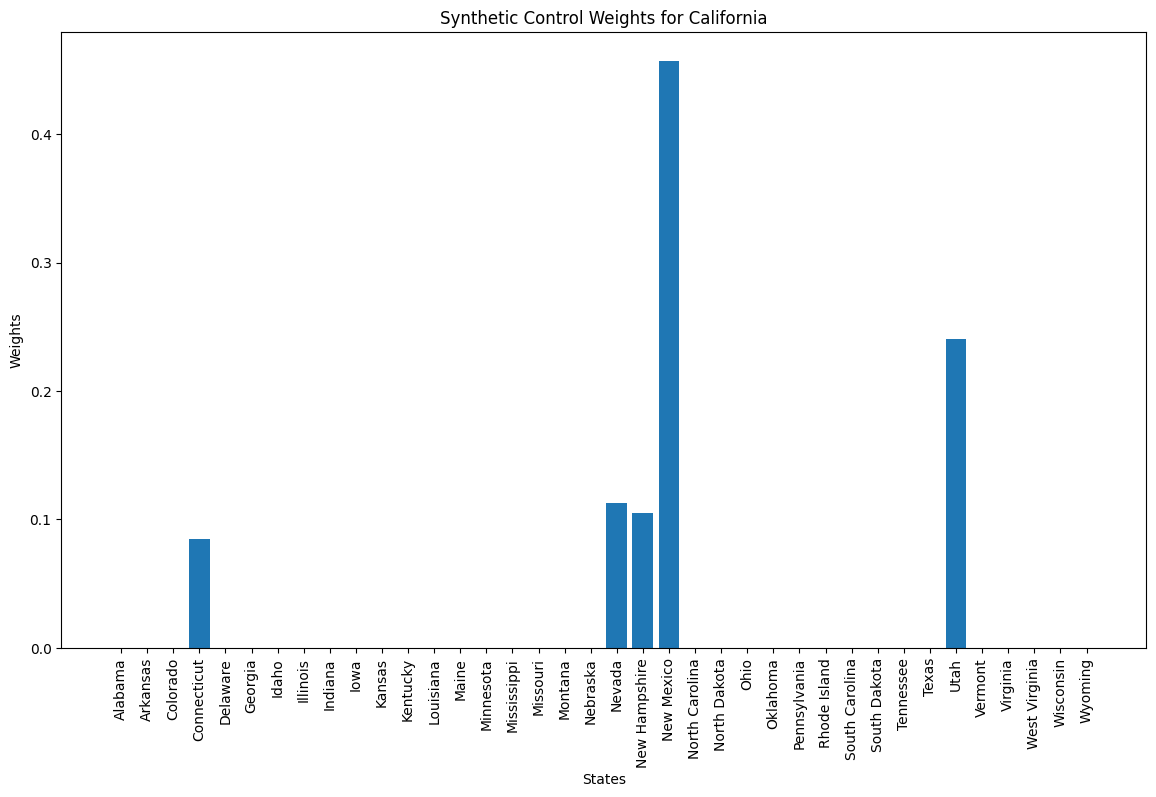

In [58]:
weights_dict = {state: weight for state, weight in zip(states, np.round(weights, 4))}

fig, ax = plt.subplots(figsize=(14, 8))
ax.bar(weights_dict.keys(), weights_dict.values())
ax.set_xlabel("States")
ax.set_ylabel("Weights")
ax.set_title("Synthetic Control Weights for California")
ax.set_xticklabels(weights_dict.keys(), rotation=90)
plt.show()

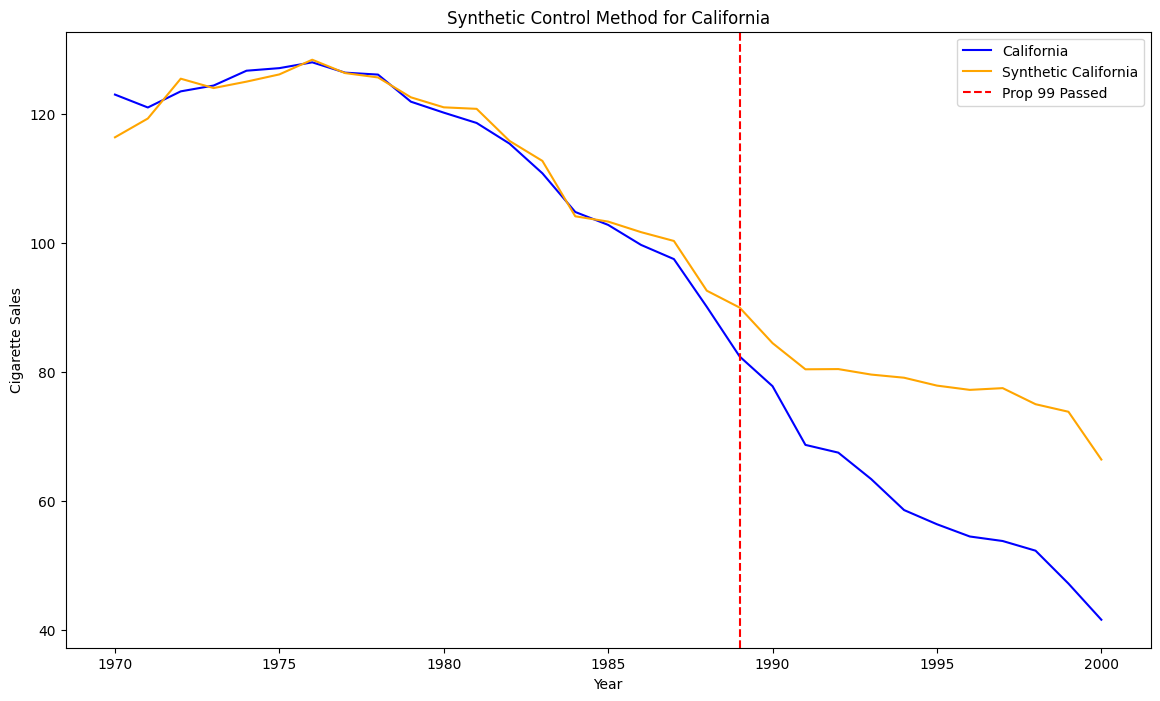

In [62]:
synthetic_california = weights @ df[df["state"] != "California"].pivot(columns="year", index="state")["cigsale"].values

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(california["year"], california["cigsale"], label="California", color="blue")
ax.plot(california["year"], synthetic_california, label="Synthetic California", color="orange")
ax.axvline(x=1989, color="red", linestyle="--", label="Prop 99 Passed")
ax.set_xlabel("Year")
ax.set_ylabel("Cigarette Sales")
ax.set_title("Synthetic Control Method for California")
ax.legend()

In [63]:
synthetic_control_effect_estimate_2000 = california[california["year"] == 2000]["cigsale"].values[0] - synthetic_california[-1]
print(f"Estimated effect of Prop 99 on cigarette sales in California by 2000 using the synthetic control method: {synthetic_control_effect_estimate_2000:.2f} packs per capita")

Estimated effect of Prop 99 on cigarette sales in California by 2000 using the synthetic control method: -24.83 packs per capita


## Diagnostics

**1 and 2 could be the same**

1. Run the same process on other units

2. Get the P-Value using Fisher (1935)

3. Change the intervention point and see if the post intervention still matches (it should)

4. Mess with V-estimation - our causal estimate shouldn't change (plot the estimates for each t for different v strats)

## Bias

- Bias if X = XW, bias otherwise

# Why Not OLS?

* overfitting

* extrapolation (negative weights)

* non-sparse interpretation is difficult

## Bibliography

Scott Cunnigham Mixtape

Abadie, Diamond, Hainmueller (2007)

Abadie (2021)